In [1]:
import pandas as pd

# PFAS Cost-Risk Analysis

## Overview
This notebook analyzes the cost-effectiveness of different PFAS treatment scenarios using UCMR5 data.

## Starting Dataset
- Source: `ep_table` from `analysis.ipynb`
- Systems: 26,148 FacilityID(Entry Points), 10,155 PWSID(water systems) with population data


## Objectives
1. Estimate treatment costs for varying regulatory thresholds (4, 8, 12, 20, 40 ng/L)
2. Calculate risk reduction (ng×person/day) for each scenario
3. Determine the cost-effectiveness of different treatment targets
4. Visualize trade-offs between costs and public health benefits

In [2]:
df = pd.read_csv('ep_table.csv')

In [3]:
df.head()

,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT,Ep_Population,Population_bin
0,AK2110342,29349,0.0,0.0,False,38526.0,19263.0,"10,001 - 50,000"
1,AK2110342,29360,0.0,0.0,False,38526.0,19263.0,"10,001 - 50,000"
2,AK2110601,10001,0.0,0.0,False,10947.0,5473.5,"3,301 - 10,000"
3,AK2110601,10004,0.0,0.0,False,10947.0,5473.5,"3,301 - 10,000"
4,AK2120232,TP001,0.0,0.0,False,8937.0,8937.0,"3,301 - 10,000"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26274 entries, 0 to 26273
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PWSID                    26274 non-null  object 
 1   FacilityID               26274 non-null  object 
 2   PFOA                     26274 non-null  float64
 3   PFOS                     26274 non-null  float64
 4   exceeds                  26274 non-null  bool   
 5   POPULATION_SERVED_COUNT  26274 non-null  float64
 6   Ep_Population            26274 non-null  float64
 7   Population_bin           26274 non-null  object 
dtypes: bool(1), float64(4), object(3)
memory usage: 1.4+ MB


In [5]:
total_exceeding_facilities = df["exceeds"].sum()

print(f'Total PWSID -> {df['PWSID'].nunique()}')
print(f'Total FacilityID (Entry Points) -> {len(df)}')
print(f'Entry points exceeding 80% Threshold (more than 0.0032 µg/L threshold)-> {total_exceeding_facilities}')
print(f"Percentage: {total_exceeding_facilities / len(df) * 100:.1f}%")

Total PWSID -> 10187
Total FacilityID (Entry Points) -> 26274
Entry points exceeding 80% Threshold (more than 0.0032 µg/L threshold)-> 2226
Percentage: 8.5%


In [6]:
df['FacilityID'].nunique()

9304

### PFAS Threshold Exceedance (4–40 ng/L)

Our dataset reports PFOA and PFOS in µg/L, we convert thresholds from ng/L → µg/L:

- 4 ng/L → 0.004 µg/L  
- 8 ng/L → 0.008 µg/L  
- 12 ng/L → 0.012 µg/L  
- 20 ng/L → 0.020 µg/L  
- 40 ng/L → 0.040 µg/L  


For each threshold, we create a column (`exceeds_4`, `exceeds_8`, …) that is True if `PFOA` or `PFOS`  exceeds the converted value.

These columns define which systems would require treatment under different regulatory scenarios.


In [7]:
df['Total_PFAS'] = df['PFOA'] + df['PFOS']

In [8]:
threshold_ng = [4,8,12,20,40]

for t in threshold_ng:
    col_name = f"exceeds_{t}"
    threshold_ug = t / 1000 # convert ng/L ->  µg/L
    df[col_name] = (df['PFOA'] > threshold_ug) | (df['PFOS'] > threshold_ug) # should exceed either chemicals

In [9]:
df.sample(10)

,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,Total_PFAS,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40
24261,UTAH27008,400W,0.00000,0.0000,False,10465.0,2616.250000,"1,001 - 3,300",0.00000,False,False,False,False,False
11147,MA4072000,10368,0.00210,0.0000,False,24630.0,6157.500000,"3,301 - 10,000",0.00210,False,False,False,False,False
21243,TX0150497,EP003,0.00000,0.0000,False,0.0,0.000000,25 - 100,0.00000,False,False,False,False,False
8996,IL1650200,20001,0.00000,0.0000,False,8460.0,8460.000000,"3,301 - 10,000",0.00000,False,False,False,False,False
22123,TX1010013,51686,0.00000,0.0000,False,2202531.0,56475.153846,"50,001 - 100,000",0.00000,False,False,False,False,False
9040,IL1835120,00001,0.00000,0.0000,False,38000.0,38000.000000,"10,001 - 50,000",0.00000,False,False,False,False,False
3052,CA1910212,91810,0.00000,0.0000,False,27072.0,5414.400000,"3,301 - 10,000",0.00000,False,False,False,False,False
15159,ND0800080,02793,0.00000,0.0000,False,72417.0,72417.000000,"50,001 - 100,000",0.00000,False,False,False,False,False
16331,NM3500326,00326001,0.00000,0.0000,False,6795.0,2265.000000,"1,001 - 3,300",0.00000,False,False,False,False,False
15609,NJ0251001,32076,0.02285,0.0094,True,61700.0,3629.411765,"3,301 - 10,000",0.03225,True,True,True,True,False


In [10]:
# rearranging the columns
df = df[
    [
        "PWSID",
        "FacilityID",
        "PFOA",
        "PFOS",
        "Total_PFAS",
        "POPULATION_SERVED_COUNT",
        "Ep_Population",
        "Population_bin",
        "exceeds",
        "exceeds_4",
        "exceeds_8",
        "exceeds_12",
        "exceeds_20",
        "exceeds_40",
    ]
]
df.sample(10)

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40
7146,GA0770002,00692,0.0,0.0,0.0,49987.0,49987.000000,"10,001 - 50,000",False,False,False,False,False,False
20004,PR0004654,00001,0.0,0.0,0.0,8961.0,8961.000000,"3,301 - 10,000",False,False,False,False,False,False
14962,NC0454010,00033,0.0,0.0,0.0,27475.0,2113.461538,"1,001 - 3,300",False,False,False,False,False,False
12578,MN1810004,6,0.0,0.0,0.0,9241.0,1848.200000,"1,001 - 3,300",False,False,False,False,False,False
18478,OK2004207,CL017,0.0,0.0,0.0,8907.0,809.727273,"501 - 1,000",False,False,False,False,False,False
22055,TX0920019,PBCU005,0.0,0.0,0.0,9021.0,4510.500000,"3,301 - 10,000",False,False,False,False,False,False
15433,NH1031010,510,0.0,0.0,0.0,6953.0,579.416667,"501 - 1,000",False,False,False,False,False,False
11816,MI0002617,05268,0.0,0.0,0.0,8473.0,8473.000000,"3,301 - 10,000",False,False,False,False,False,False
8158,ID3140013,11092,0.0,0.0,0.0,74000.0,4933.333333,"3,301 - 10,000",False,False,False,False,False,False
13491,MS0220003,39244,0.0,0.0,0.0,12762.0,4254.000000,"3,301 - 10,000",False,False,False,False,False,False


In [11]:
# Ep_Population is population served per entry point (total population / number of entry points)
# This calculation produces floats, so we round to whole numbers for clarity
df['Ep_Population'] = df['Ep_Population'].round()

In [12]:
print("=== Number of Entry Points Exceeding Each Threshold ===")
for t in threshold_ng:
    col = f"exceeds_{t}"
    count = df[col].sum()
    percent = (count / len(df)) * 100
    pop = df.loc[df[col] == 1, "Ep_Population"].sum()
    print(f"{t} ng/L: {count:,} FacilityId/EntryPoints ({percent:.2f}%), Population affected: {pop:,}")

=== Number of Entry Points Exceeding Each Threshold ===
4 ng/L: 2,079 FacilityId/EntryPoints (7.91%), Population affected: 28,646,863.0
8 ng/L: 948 FacilityId/EntryPoints (3.61%), Population affected: 13,147,528.0
12 ng/L: 486 FacilityId/EntryPoints (1.85%), Population affected: 7,997,068.0
20 ng/L: 187 FacilityId/EntryPoints (0.71%), Population affected: 3,008,001.0
40 ng/L: 39 FacilityId/EntryPoints (0.15%), Population affected: 304,440.0


### Risk Reduction Based on Drinking Water Intake (ng/day)

The EPA assumes the average adult consumes 2 liters per day of tap water.  
Therefore, PFAS exposure per facility id is estimated as:

$$
\text{ng/day total} = (\text{PFOA} + \text{PFOS})_{\mu g/L} 
\times 2\ \text{L/day/person} 
\times \text{Population Served} 
\times 1000\ \text{ng}/\mu g
$$


This value represents the total PFAS exposure per day for all people served by that entry point.


In [13]:
df["exposure_per_day(ng)"] = (df["Total_PFAS"] * 1000 * 2 * df["Ep_Population"])

In [14]:
df.sample(10)

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40,exposure_per_day(ng)
25837,WI2680239,00200T,0.000000,0.0,0.000000,6419.0,2140.0,"1,001 - 3,300",False,False,False,False,False,False,0.0
13396,MS0060008,TF103,0.000000,0.0,0.000000,341.0,170.0,101 - 500,False,False,False,False,False,False,0.0
16304,NJ1924316,TP001001,0.000000,0.0,0.000000,1750.0,1750.0,"1,001 - 3,300",False,False,False,False,False,False,0.0
11313,MA4264000,00023,0.001325,0.0,0.001325,19297.0,4824.0,"3,301 - 10,000",False,False,False,False,False,False,12783.6
10559,LA1103005,44004,0.000000,0.0,0.000000,10791.0,5396.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
3800,CA3410001,81871,0.000000,0.0,0.000000,194444.0,3411.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
6481,FL3480149,1,0.000000,0.0,0.000000,6157.0,6157.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
13561,MS0240009,TF105,0.000000,0.0,0.000000,10272.0,2054.0,"1,001 - 3,300",False,False,False,False,False,False,0.0
5691,CT0070011,20001,0.000000,0.0,0.000000,7553.0,3776.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
1882,AZ0413048,13048101,0.000000,0.0,0.000000,57048.0,3003.0,"1,001 - 3,300",False,False,False,False,False,False,0.0


### Average PFAS Exposure Reduction (ng/day/person)

To describe how PFAS burden is distributed among affected populations, we divide the total PFAS burden proxy (ng/day) from all **entry points** exceeding a given threshold by the total population served by those entry points:

$$
\text{ng/day/person}_T
=
\frac{\text{ng/day total}_T}{\text{Population}_T}
$$

This represents the average PFAS mass per person per day among people served by Facility ID exceeding threshold \(T\).

In [15]:
df.head()

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40,exposure_per_day(ng)
0,AK2110342,29349,0.0,0.0,0.0,38526.0,19263.0,"10,001 - 50,000",False,False,False,False,False,False,0.0
1,AK2110342,29360,0.0,0.0,0.0,38526.0,19263.0,"10,001 - 50,000",False,False,False,False,False,False,0.0
2,AK2110601,10001,0.0,0.0,0.0,10947.0,5474.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
3,AK2110601,10004,0.0,0.0,0.0,10947.0,5474.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
4,AK2120232,TP001,0.0,0.0,0.0,8937.0,8937.0,"3,301 - 10,000",False,False,False,False,False,False,0.0


In [16]:
bin_order = [
    '25 - 100', 
    '101 - 500', 
    '501 - 1,000', 
    '1,001 - 3,300', 
    '3,301 - 10,000', 
    '10,001 - 50,000', 
    '50,001 - 100,000', 
    '100,001 - 1,000,000', 
    '> 1,000,000'
]

In [17]:
# Average PFAS Exposure Reduction per Impacted Entry Point (ng/day), categorized by Population Bin and Regulatory Threshold.

#initialize the dictionary
avg_exposure_reduction_map = {}

for t in threshold_ng:
    # 'True/False' for the threshold
    exceed_col = f'exceeds_{t}'
    
    # only include EPs that exceed the threshold
    exceeding = df.loc[df[exceed_col] == True]
    
    #  Mean: (Sum of exposure) / (Count of True) per bin
    #  Average Reduction per EP
    avg_per_bin = exceeding.groupby('Population_bin')['exposure_per_day(ng)'].mean()
    
   
    avg_exposure_reduction_map[f'{t}ng/L'] = avg_per_bin.round()

avg_reduction_df = pd.DataFrame(avg_exposure_reduction_map)
avg_reduction_df = avg_reduction_df.reindex(bin_order).fillna(0)

avg_reduction_df 

,4ng/L,8ng/L,12ng/L,20ng/L,40ng/L
Population_bin,,,,,
25 - 100,1589.0,3095.0,4720.0,4720.0,4720.0
101 - 500,11124.0,22664.0,47035.0,107385.0,107385.0
"501 - 1,000",25502.0,43009.0,55798.0,81790.0,140318.0
"1,001 - 3,300",62736.0,93965.0,133315.0,196085.0,296303.0
"3,301 - 10,000",150583.0,236909.0,319060.0,443430.0,751485.0
"10,001 - 50,000",658318.0,1017737.0,1324145.0,1946727.0,2801701.0
"50,001 - 100,000",2334359.0,3123850.0,3879922.0,5239583.0,9503000.0
"100,001 - 1,000,000",7081975.0,10408752.0,10736261.0,25256444.0,0.0
"> 1,000,000",0.0,0.0,0.0,0.0,0.0


### National Scaling Methodology: Brief Overview

To move from the UCMR5 sample to a National Estimate, we followed these core steps:

- **Total Active Water Systems:**  
  Determined the total count of Public Water Systems (PWSs) using SDWIS inventory data to establish the true size of U.S. infrastructure.

- **Impacted Entry Points (EPs):**  
  Used the UCMR5 dataset to calculate the impact rate by dividing the number of systems exceeding a specific threshold by the total number of systems in the cleaned dataset.

- **Vector Calculation:**  
  Created a vector across all population bins to total EPs in UCMR5, and divided the "# impacted systems" vector by the "total systems" vector to compute the percentage of impacted systems for each threshold.

- **National Scaling:**  
  Applied these percentages to the total national PWS count to scale the findings to represent the entire United States.

This Scaling Table represents the final result of that process. It summarizes the total national population protected, the mass of PFAS removed, and the total annual cost for the entire country.

- **Note:**  For the full step-by-step calculations, population updates, and Python logic, please check out the Scaling Notebook in the project directory.


In [18]:
scaling_table = pd.read_csv('final_national_impact.csv')

In [19]:
scaling_table

,Population_bin,National_PWS_Count,Estimated_EPs_to_Treat_4ng,Estimated_EPs_to_Treat_8ng,Estimated_EPs_to_Treat_12ng,Estimated_EPs_to_Treat_20ng,Estimated_EPs_to_Treat_40ng
0,25 - 100,11385,3022.0,863.0,432.0,432.0,432.0
1,101 - 500,15098,2301.0,802.0,401.0,101.0,101.0
2,"501 - 1,000",5336,1748.0,897.0,603.0,263.0,62.0
3,"1,001 - 3,300",7972,2163.0,1182.0,652.0,302.0,93.0
4,"3,301 - 10,000",5000,1582.0,743.0,387.0,153.0,25.0
5,"10,001 - 50,000",3513,1070.0,514.0,313.0,146.0,25.0
6,"50,001 - 100,000",583,137.0,63.0,39.0,12.0,4.0
7,"100,001 - 1,000,000",455,185.0,71.0,65.0,18.0,0.0
8,"> 1,000,000",27,0.0,0.0,0.0,0.0,0.0


In [20]:
national_exposure_dict = {}

for t in threshold_ng:
    val_col = f"{t}ng/L"                          # Average exposure reduction per EP (from our sample)
    qty_col = f"Estimated_EPs_to_Treat_{t}ng"    # National count of EPs (from scaling notebook)
  
    # Align the National EP Count and Average Exposure Reduction by their Population Bin
    quantities = scaling_table.set_index('Population_bin')[qty_col]
    unit_reductions = avg_reduction_df[val_col]
    
    # Calculate Total National Reduction: (Count of EPs) * (Avg Exposure Reduction per EP)
    # This scales our local data to estimate the total mass removed across the U.S.
    total_reduction = (quantities * unit_reductions).sum()
 
    # Store the final rounded total (in nanograms/day) for this threshold
    national_exposure_dict[t] = total_reduction.round()

national_exposure_dict

{4: np.float64(2783268870.0),
 8: np.float64(1805457363.0),
 12: np.float64(1528575177.0),
 20: np.float64(963171285.0),
 40: np.float64(175982470.0)}

In [21]:
national_exposure_df = pd.DataFrame(list(national_exposure_dict.items()), 
                                    columns=['Threshold_ngL', 'National_Exposure_Reduction_ng_day'])

national_exposure_df = national_exposure_df.sort_values('Threshold_ngL')

national_exposure_df.style.format({
    'National_Exposure_Reduction_ng_day': '{:,.0f}'
})

,Threshold_ngL,National_Exposure_Reduction_ng_day
0,4,"2,783,268,870"
1,8,"1,805,457,363"
2,12,"1,528,575,177"
3,20,"963,171,285"
4,40,"175,982,470"


In [22]:
# National Weighted Concentration  
national_avg_conc_list = []

for t in threshold_ng:
    exceed_col = f'exceeds_{t}'
    
    # filter raw data for systems exceeding the current threshold
    treated = df[df[exceed_col] == True].copy()
    
    #  Calculate Mass-Weighted Population (Conc * Pop)
    # Total_PFAS is in µg/L, so * 1000 converts it to ng/L
    treated['Mass_Weighted_Pop'] = treated['Total_PFAS'] * 1000 * treated['Ep_Population']
    
    #  Group by bin to get totals per population category
    bin_stats = treated.groupby('Population_bin').agg({
        'Mass_Weighted_Pop': 'sum',
        'Ep_Population': 'sum'
    })
    
    # National Scaling: Calculate the weighted average across all bins
    national_num = bin_stats['Mass_Weighted_Pop'].sum()
    national_den = bin_stats['Ep_Population'].sum()
    
    avg_conc = (national_num / national_den) if national_den > 0 else 0
    national_avg_conc_list.append({
        'Threshold_ngL': t,
        'National_Avg_Conc_ngL': round(avg_conc, 2)
    })


national_conc_df = pd.DataFrame(national_avg_conc_list).sort_values('Threshold_ngL')


national_conc_df.style.format({'National_Avg_Conc_ngL': '{:.2f} ng/L'})

,Threshold_ngL,National_Avg_Conc_ngL
0,4,14.89 ng/L
1,8,22.62 ng/L
2,12,27.88 ng/L
3,20,40.49 ng/L
4,40,66.01 ng/L


### National Annualized Cost Calculation

- **Cost Mapping:**  
  Assigned an annual cost per entry point based on population bins using engineering estimates from the Corona memo.

- **Bin-by-Bin Calculation:**  
  For each threshold, multiply the estimated national number of entry points in each bin by its corresponding cost factor (e.g., $0.07M for the smallest systems, $4.76M for the largest).

- **National Total:**  
  Summed costs across all bins to estimate total annual investment ($M/year) for the United States.

In [23]:
# mapping population bin with facility annualized cost column of Table 4 in the Corona memo
popbin_cost_map = {
    '25 - 100': 0.07, '101 - 500': 0.12, '501 - 1,000': 0.17,
    '1,001 - 3,300': 0.25, '3,301 - 10,000': 0.40, '10,001 - 50,000': 0.76,
    '50,001 - 100,000': 1.29, '100,001 - 1,000,000': 2.33, '> 1,000,000': 4.76
}

national_costs = {}

for t in threshold_ng:
  
    ep_col = f'Estimated_EPs_to_Treat_{t}ng'
    
    # Cost = Sum of (National EPs in Bin * Bin's Annualized Cost)
    bin_total = (scaling_table[ep_col] * scaling_table['Population_bin'].map(popbin_cost_map)).sum()
    national_costs[t] = round(bin_total, 2)

print("National Annualized Costs ($M):", national_costs)

National Annualized Costs ($M): {4: np.float64(3379.35), 8: np.float64(1539.18), 12: np.float64(938.31), 20: np.float64(392.15), 40: np.float64(110.31)}


In [24]:
national_costs_df = pd.DataFrame(national_costs.items(), columns=['Threshold_ngL', 'National Annualized Costs ($M):'])
national_costs_df

,Threshold_ngL,National Annualized Costs ($M):
0,4,3379.35
1,8,1539.18
2,12,938.31
3,20,392.15
4,40,110.31


### National Cost-Effectiveness Calculation

We want to know exactly how much it costs the United States to remove one nanogram of PFAS from our water.

- **Total Annual Cost ($M$)**  
  Converted costs from millions ($M$) to actual dollars by multiplying by \( 1{,}000{,}000 \) (1e6).

- **Total Yearly PFAS Removed ($ng$):**  
  Converted daily PFAS removal (\( ng/day \)) to annual removal by multiplying by 365 days.

- **The Efficiency Ratio ($/ng$)**  
  Divided total annual cost by the total annual PFAS removed.

In [25]:
ce_results = []

for t in threshold_ng:

    daily_ng_reduction = national_exposure_dict[t] 
    
    # Convert to Annual and Dollars
    total_annual_cost_dollars = national_costs[t] * 1e6
    annual_ng_reduction = daily_ng_reduction * 365
    
    
    cost_effectiveness = total_annual_cost_dollars / annual_ng_reduction
    
    ce_results.append({
        "Threshold (ng/L)": t,
        "Total Annual Cost ($M)": national_costs[t],
        "Annual Exposure Reduction (ng)": annual_ng_reduction,
        "Cost-Effectiveness ($/ng)": cost_effectiveness
    })

cost_effectiveness_df = pd.DataFrame(ce_results)


cost_effectiveness_df.style.format({
    "Total Annual Cost ($M)": "${:,.2f}M",
    "Annual Exposure Reduction (ng)": "{:,.0e}", 
    "Cost-Effectiveness ($/ng)": "${:,.10f}"
})

,Threshold (ng/L),Total Annual Cost ($M),Annual Exposure Reduction (ng),Cost-Effectiveness ($/ng)
0,4,"$3,379.35M",1e+12,$0.0033264818
1,8,"$1,539.18M",7e+11,$0.0023356583
2,12,$938.31M,6e+11,$0.0016817703
3,20,$392.15M,4e+11,$0.0011154647
4,40,$110.31M,6e+10,$0.0017173255


In [26]:
summary_results = []

for t in threshold_ng:
    # Cost from  national_costs dict
    cost = national_costs[t]
    
    # Pull Exposure from national_exposure_dict
    exposure_daily = national_exposure_dict[t]
    
    
    annual_reduction_ng = exposure_daily * 365
    ce_value = (cost * 1e6) / annual_reduction_ng
    
    summary_results.append({
        "Threshold (ng/L)": t,
        "Total National Cost ($M)": cost,
        "Daily Exposure Reduction (ng/day)": exposure_daily,
        "Cost-Effectiveness ($/ng)": ce_value
    })

summary_df = pd.DataFrame(summary_results)


summary_df.style.format({
    "Total National Cost ($M)": "${:,.2f}M",
    "Daily Exposure Reduction (ng/day)": "{:,.0f}",
    "Cost-Effectiveness ($/ng)": "${:,.10f}"
})

,Threshold (ng/L),Total National Cost ($M),Daily Exposure Reduction (ng/day),Cost-Effectiveness ($/ng)
0,4,"$3,379.35M","2,783,268,870",$0.0033264818
1,8,"$1,539.18M","1,805,457,363",$0.0023356583
2,12,$938.31M,"1,528,575,177",$0.0016817703
3,20,$392.15M,"963,171,285",$0.0011154647
4,40,$110.31M,"175,982,470",$0.0017173255


### Figure 1: Total PFAS Exposure Removed (ng/day) vs National Annualized Cost

This figure shows the total PFAS burden proxy (ng/day) removed nationwide under each regulatory threshold, plotted against the corresponding national annualized treatment cost (million dollars). Lower thresholds remove a larger share of the total PFAS burden but require higher treatment costs, while higher thresholds remove less PFAS burden at lower cost. Results are based on Corona-scaled entry-point (Facility ID) exceedances.


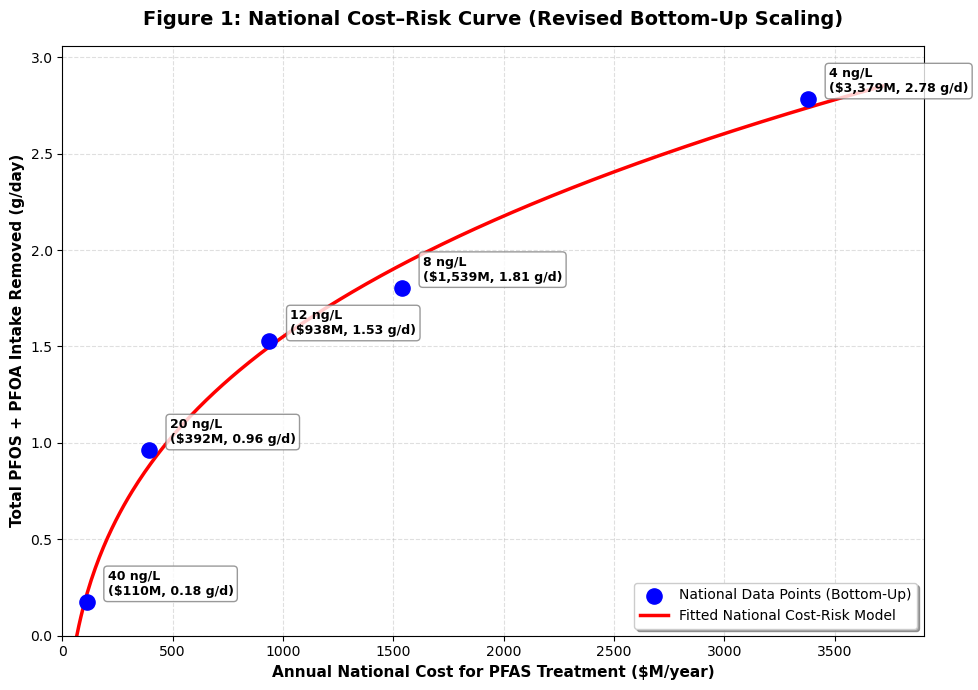

Final Model: y = -1.322 + 2.873 * (x/1000)^0.284


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


fig1_costs_M = np.array([national_costs[t] for t in threshold_ng])
fig1_exposure = np.array([national_exposure_dict[t] / 1e9 for t in threshold_ng])

# Power-Law Model and Fit it to the data
def cost_risk_model(x, a, b, c):
    return a + b * ((x / 1000) ** c)

# Find the best coefficients (a, b, c) 
popt, _ = curve_fit(cost_risk_model, fig1_costs_M, fig1_exposure, p0=[-0.78, 1.96, 0.35])

#  curve line for plotting
x_range = np.linspace(0, fig1_costs_M.max() * 1.1, 400)
y_curve = cost_risk_model(x_range, *popt)

# Plotting
plt.figure(figsize=(10, 7))

# Plot the Data Points (Blue Dots)
plt.scatter(fig1_costs_M, fig1_exposure, color='blue', s=120, label='National Data Points (Bottom-Up)', zorder=3)

# Plot the Fitted Model (Red Line)
plt.plot(x_range, y_curve, color='red', linewidth=2.5, label='Fitted National Cost-Risk Model', zorder=2)

# Annotate each point with Threshold, Cost, and Grams/day
for t, x, y in zip(threshold_ng, fig1_costs_M, fig1_exposure):
    label = f"{t} ng/L\n(${x:,.0f}M, {y:,.2f} g/d)"
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(15, 5), 
                 fontsize=9, fontweight='bold', ha='left',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, edgecolor='gray'))


plt.xlabel("Annual National Cost for PFAS Treatment ($M/year)", fontsize=11, fontweight='bold')
plt.ylabel("Total PFOS + PFOA Intake Removed (g/day)", fontsize=11, fontweight='bold')
plt.title("Figure 1: National Cost–Risk Curve (Revised Bottom-Up Scaling)", fontsize=14, pad=15, fontweight='bold')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.tight_layout()

# Save and Show
plt.savefig('national_cost_risk_curve.png', dpi=300)
plt.show()

# print the formula
print(f"Final Model: y = {popt[0]:.3f} + {popt[1]:.3f} * (x/1000)^{popt[2]:.3f}")

### Figure 1a: National Average PFAS Concentration
This figure shows the average combined PFAS concentration (PFOA + PFOS) in the water systems that would require treatment at each regulatory level.

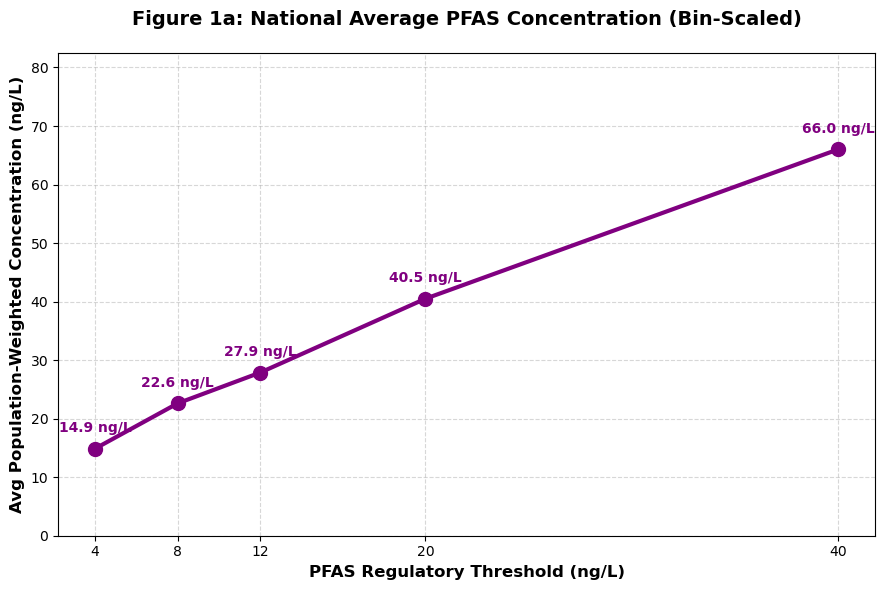

In [28]:
# --- Plotting Figure 1b: National Weighted Concentration ---
plt.figure(figsize=(9, 6))

# Plotting the line and markers
plt.plot(national_conc_df['Threshold_ngL'], 
         national_conc_df['National_Avg_Conc_ngL'], 
         marker='o', color='purple', linewidth=3, markersize=10, 
         label='Weighted Avg Concentration')

# Add data labels above each point
for i, row in national_conc_df.iterrows():
    plt.annotate(f"{row['National_Avg_Conc_ngL']:.1f} ng/L", 
                 (row['Threshold_ngL'], row['National_Avg_Conc_ngL']), 
                 textcoords="offset points", xytext=(0, 12), 
                 ha='center', fontweight='bold', color='purple')

# Formatting the Chart
plt.xlabel('PFAS Regulatory Threshold (ng/L)', fontsize=12, fontweight='bold')
plt.ylabel("Avg Population-Weighted Concentration (ng/L)", fontsize=12, fontweight='bold')
plt.title('Figure 1a: National Average PFAS Concentration (Bin-Scaled)', fontsize=14, pad=20, fontweight='bold')

# Set the X-axis to show only your specific thresholds
plt.xticks(threshold_ng)

# Ensure the Y-axis starts at zero and has some "headroom" for labels
plt.ylim(0, national_conc_df['National_Avg_Conc_ngL'].max() * 1.25)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the figure
plt.savefig('figure_1b_national_concentration.png', dpi=300)
plt.show()

### Figure 2: National Cost-Effectiveness of PFAS Treatment by Threshold

This figure shows the economic efficiency for each threshold. We calculate this by dividing the total annual cost by the total weight (in grams) of PFAS removed each year. A lower value on the graph means the threshold is more efficient. It represents the price to remove one gram of PFAS from the national water supply. These results are scaled to the national level using the verified multiplier ($M = 2.5749$).

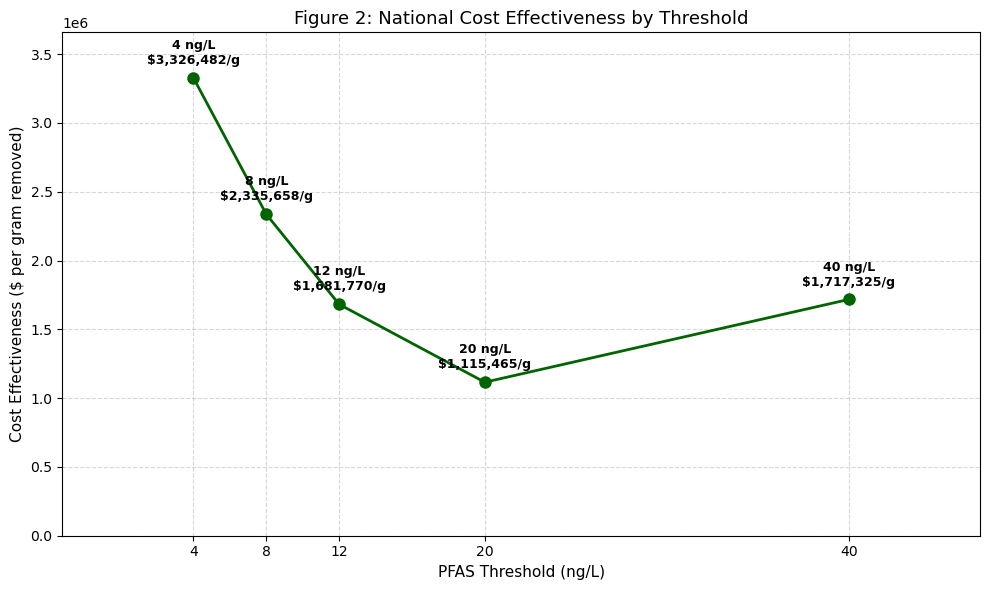

In [29]:
# multiply $/ng by 1e9 to get $/gram
ce_vals_per_gram = []
for t in threshold_ng:
    # Get the value from the 'Cost-Effectiveness ($/ng)' column
    val_ng = cost_effectiveness_df.loc[cost_effectiveness_df['Threshold (ng/L)'] == t, 'Cost-Effectiveness ($/ng)'].values[0]
    ce_vals_per_gram.append(float(val_ng) * 1e9)
    
plt.figure(figsize=(10, 6))
plt.plot(threshold_ng, ce_vals_per_gram, marker='o', color='darkgreen', linewidth=2, markersize=8)

# add space for labels
plt.margins(x=0.2, y=0.15)


for t, y in zip(threshold_ng, ce_vals_per_gram):
    plt.annotate(
        f"{t} ng/L\n${y:,.0f}/g", 
        (t, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.xlabel("PFAS Threshold (ng/L)", fontsize=11)
plt.ylabel("Cost Effectiveness ($ per gram removed)", fontsize=11)
plt.title("Figure 2: National Cost Effectiveness by Threshold", fontsize=13)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(threshold_ng)
plt.tight_layout()
plt.show()

In [30]:
overall_exceedance = {}

total_systems = len(df)

for t in threshold_ng:
    col = f"exceeds_{t}"
    overall_exceedance[t] = df[col].mean() * 100   # % of entry points

### Figure 3: Percent of Entry Points Exceeding PFAS Thresholds

This figure shows (1) the percent of drinking-water entry points within each population bin that exceed each PFAS threshold, and (2) the overall percent of all U.S. entry points exceeding each threshold. Results are based on UCMR5 observations and reported for descriptive comparison across system sizes.


In [31]:
# compute percentage % exceeding per bin
exceed_by_bin = df.groupby("Population_bin")[[f"exceeds_{t}" for t in threshold_ng]].mean() * 100

# reorder bins properly if needed
bin_order = ['25 - 100','101 - 500','501 - 1,000','1,001 - 3,300',
             '3,301 - 10,000','10,001 - 50,000','50,001 - 100,000',
             '100,001 - 1,000,000','> 1,000,000']

exceed_by_bin = exceed_by_bin.reindex(bin_order)


In [32]:
exceed_by_bin

,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40
Population_bin,,,,,
25 - 100,6.923077,1.538462,0.769231,0.769231,0.769231
101 - 500,4.531722,1.812689,0.755287,0.302115,0.302115
"501 - 1,000",7.091011,3.405918,2.177554,0.949190,0.223339
"1,001 - 3,300",7.137264,3.501510,1.633292,0.648842,0.190178
"3,301 - 10,000",8.194965,3.417247,1.638993,0.578468,0.074987
"10,001 - 50,000",9.325843,4.314607,2.449438,0.966292,0.157303
"50,001 - 100,000",8.631922,4.885993,2.931596,1.465798,0.162866
"100,001 - 1,000,000",12.103746,5.475504,4.322767,0.864553,0.000000
"> 1,000,000",0.000000,0.000000,0.000000,0.000000,0.000000


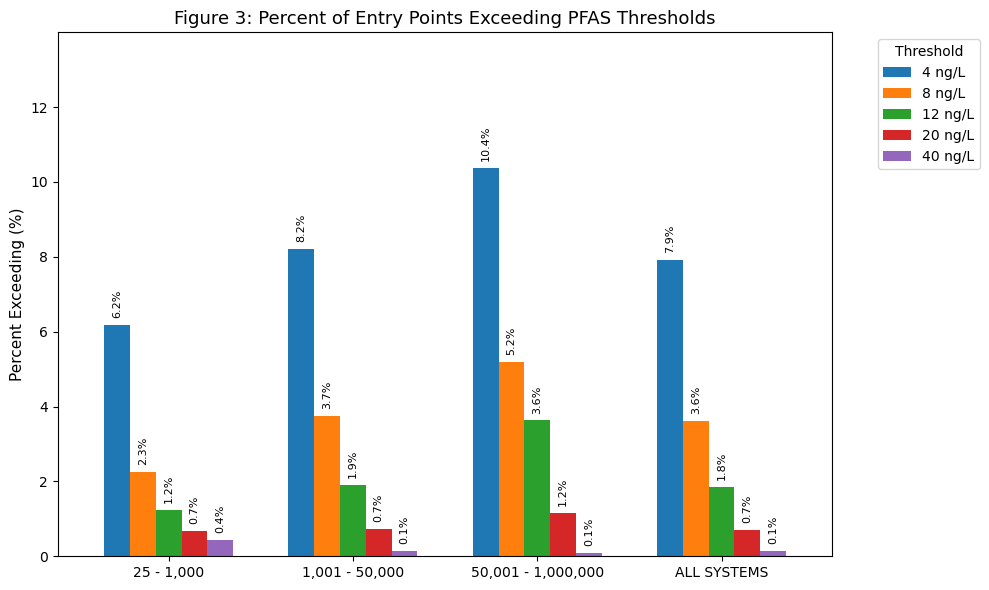

In [33]:
bin_groups = {
    '25 - 1,000': ['25 - 100', '101 - 500', '501 - 1,000'],
    '1,001 - 50,000': ['1,001 - 3,300', '3,301 - 10,000', '10,001 - 50,000'],
    '50,001 - 1,000,000': ['50,001 - 100,000', '100,001 - 1,000,000']
}


combined_rows = {}
for group_label, bins in bin_groups.items():
    group_data = exceed_by_bin.loc[exceed_by_bin.index.isin(bins)]
    combined_rows[group_label] = group_data.mean()

combined_df = pd.DataFrame(combined_rows).T


combined_df.columns = [f'exceeds_{t}' for t in threshold_ng]


combined_df.loc['ALL SYSTEMS'] = [overall_exceedance[t] for t in threshold_ng]

fig, ax = plt.subplots(figsize=(10, 6))
combined_df.plot(kind='bar', ax=ax, width=0.7)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8,
                    rotation=90,
                    xytext=(0, 5),
                    textcoords='offset points')

plt.title("Figure 3: Percent of Entry Points Exceeding PFAS Thresholds", fontsize=13)
plt.ylabel("Percent Exceeding (%)", fontsize=11)
plt.ylim(0, combined_df.max().max() * 1.35)
plt.xticks(rotation=0, ha='center')
plt.legend(title="Threshold", labels=['4 ng/L','8 ng/L','12 ng/L','20 ng/L','40 ng/L'],
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('figure3A_combined_bins.png', dpi=150, bbox_inches='tight')
plt.show()

Population bins are grouped into three ranges: 25–1,000, 1,001–50,000, and 50,001–1,000,000. Systems serving more than 1,000,000 people (n=6 entry points) are excluded from this figure as no entry points in that category exceeded any threshold at any regulatory level evaluated (4–40 ng/L). Percentages within each combined bin represent the average exceedance rate across the constituent EPA population bins.

### Figure 3A: Distribution of Max(PFOA, PFOS) Concentrations by Population Size
This figure shows the actual range of PFAS levels found in different water systems.

Two versions of this graph:

Normal (Linear) Scale: Best for seeing the true physical difference between high and low values. However, very high "outlier" points can make the lower boxes look squashed.

Log Scale: Best for seeing the detail in lower concentrations. It uses powers of 10 on the vertical axis, which prevents the high outliers from hiding the patterns in the rest of the data.

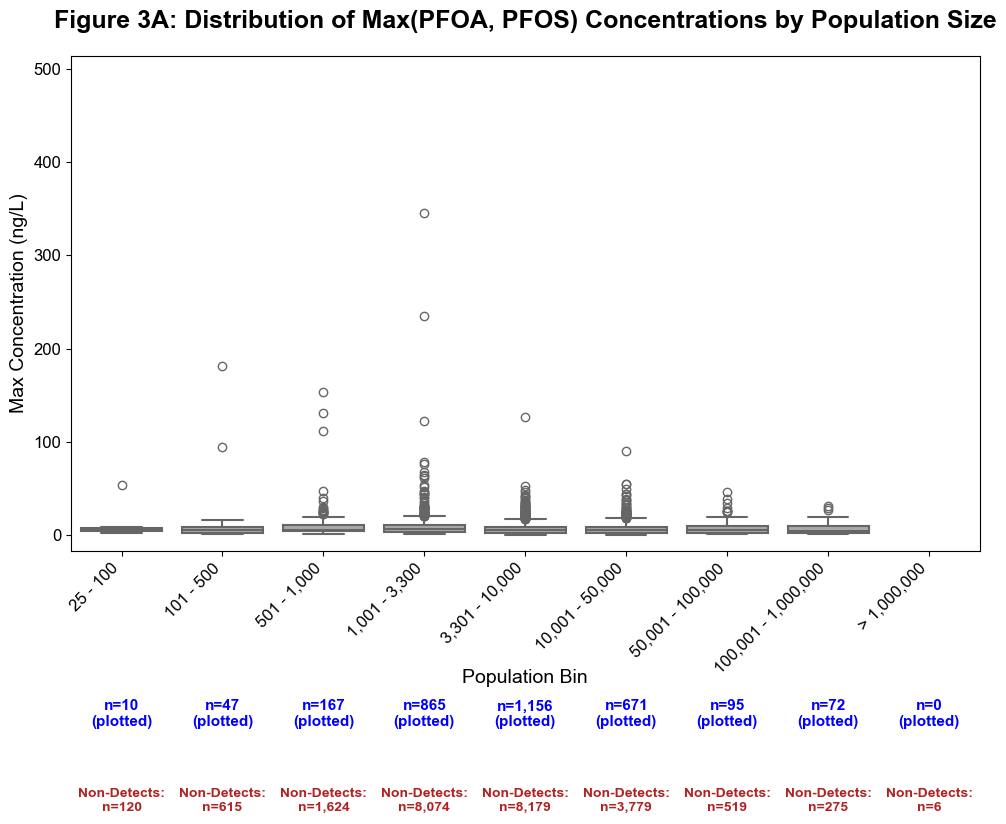

Saved: figure3A_linear.png


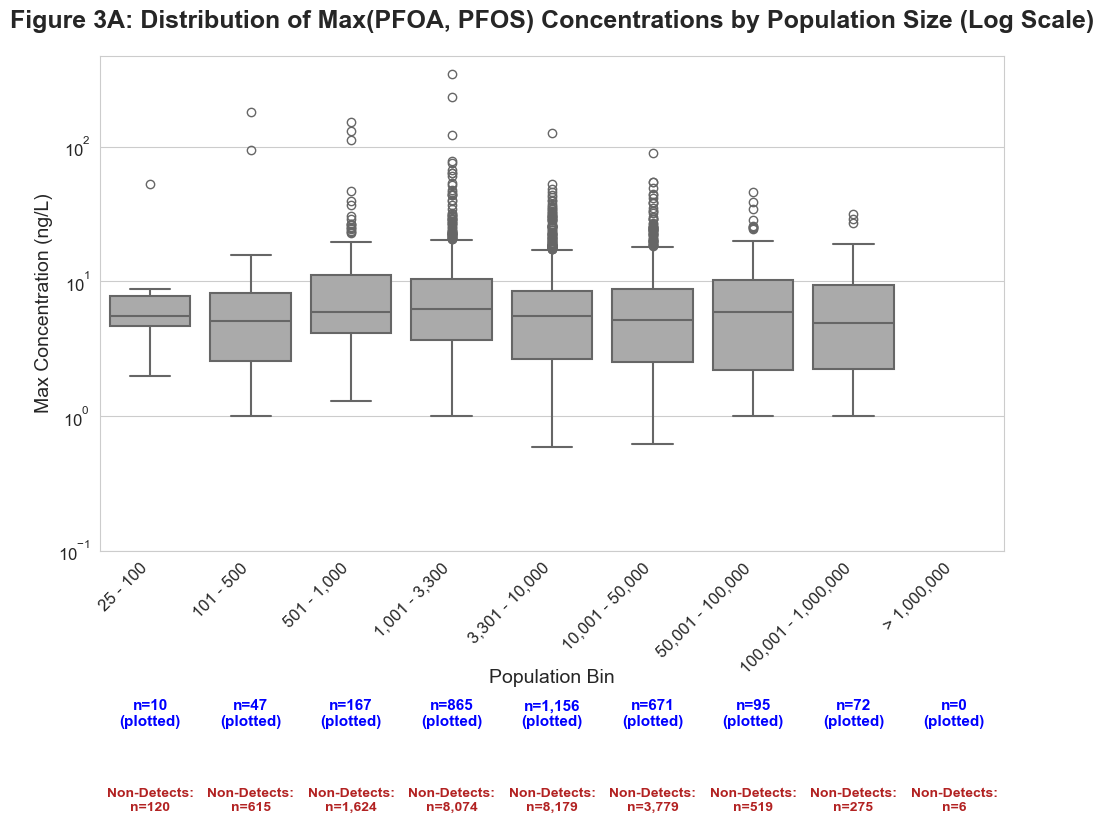

Saved: figure3A_log.png


In [34]:
import seaborn as sns

df['max_pfas_conc_ng'] = df[['PFOA','PFOS']].max(axis=1) * 1000

n_detected = df[df['max_pfas_conc_ng'] > 0].groupby('Population_bin').size().reindex(bin_order).fillna(0).astype(int)
n_below = df[df['max_pfas_conc_ng'] == 0].groupby('Population_bin').size().reindex(bin_order).fillna(0).astype(int)

df_detections = df[df['max_pfas_conc_ng'] > 0]

def make_figure(log_scale=False):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.set_style("whitegrid")
    
    
    sns.boxplot(
        data=df_detections,
        x='Population_bin',
        y='max_pfas_conc_ng',
        order=bin_order,
        color='#AAAAAA',   # uniform grey — no color differentiation
        showfliers=True,
        ax=ax,
        linewidth=1.5
    )

    suffix = " (Log Scale)" if log_scale else ""
    ax.set_title(
        f"Figure 3A: Distribution of Max(PFOA, PFOS) Concentrations by Population Size{suffix}",
        fontsize=18, pad=20, fontweight='bold'
    )
    ax.set_ylabel("Max Concentration (ng/L)", fontsize=14)
    ax.set_xlabel("Population Bin", fontsize=14, labelpad=-5)
    ax.tick_params(axis='both', labelsize=12)
    plt.xticks(rotation=45, ha='right')

    if log_scale:
        ax.set_yscale('log')
        ax.set_ylim(bottom=0.1)   # avoid log(0) issues
    else:
        y_min, y_max = ax.get_ylim()
        ax.set_ylim(y_min, y_max + (y_max - y_min) * 0.4)

    for i, bin_name in enumerate(bin_order):
        plt.text(i, -0.30, f"n={n_detected[bin_name]:,}\n(plotted)",
                 transform=ax.get_xaxis_transform(),
                 ha='center', va='top', fontsize=11, color='blue', fontweight='bold')
        plt.text(i, -0.48, f"Non-Detects:\nn={n_below[bin_name]:,}",
                 transform=ax.get_xaxis_transform(),
                 ha='center', va='top', fontsize=10, color='firebrick', fontweight='bold')

    plt.subplots_adjust(bottom=0.35)
    plt.tight_layout()
    fname = "figure3A_log.png" if log_scale else "figure3A_linear.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

make_figure(log_scale=False)
make_figure(log_scale=True)


In [35]:
# checking if any entry points with pop bin > 1,000,000 has exceeded any threshold
exceed_by_bin.loc["> 1,000,000"]

exceeds_4     0.0
exceeds_8     0.0
exceeds_12    0.0
exceeds_20    0.0
exceeds_40    0.0
Name: > 1,000,000, dtype: float64

In [36]:
# no. of entry points with pop bin > 1,000,000 
(df["Population_bin"] == "> 1,000,000").sum()

np.int64(6)

In [37]:
# all the entry point with pop bin > 1,000,000. did all of this cause the graph showed no bins
df.loc[df["Population_bin"] == "> 1,000,000"]

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40,exposure_per_day(ng),max_pfas_conc_ng
8560,IL0316000,00001,0.0,0.0,0.0,2746388.0,1373194.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0
8561,IL0316000,00002,0.0,0.0,0.0,2746388.0,1373194.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0
17847,NY7003493,94001,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0
17848,NY7003493,94002,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0
17849,NY7003493,94003,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0
17850,NY7003493,94004,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0


### Figure 3b: Distributed of Max(PFOA, PFOS) Concentrations (Full Sample)
Unlike the previous chart that focused only on detections, this boxplot includes the non-detects. This gives a more realistic look at the median contamination levels across the country, as most systems actually sit at the bottom of the scale.

The codes after the graph is to verify if the population bin more than 1 million didnt really have any Facility ID that exceeded any regulatory thresholds.

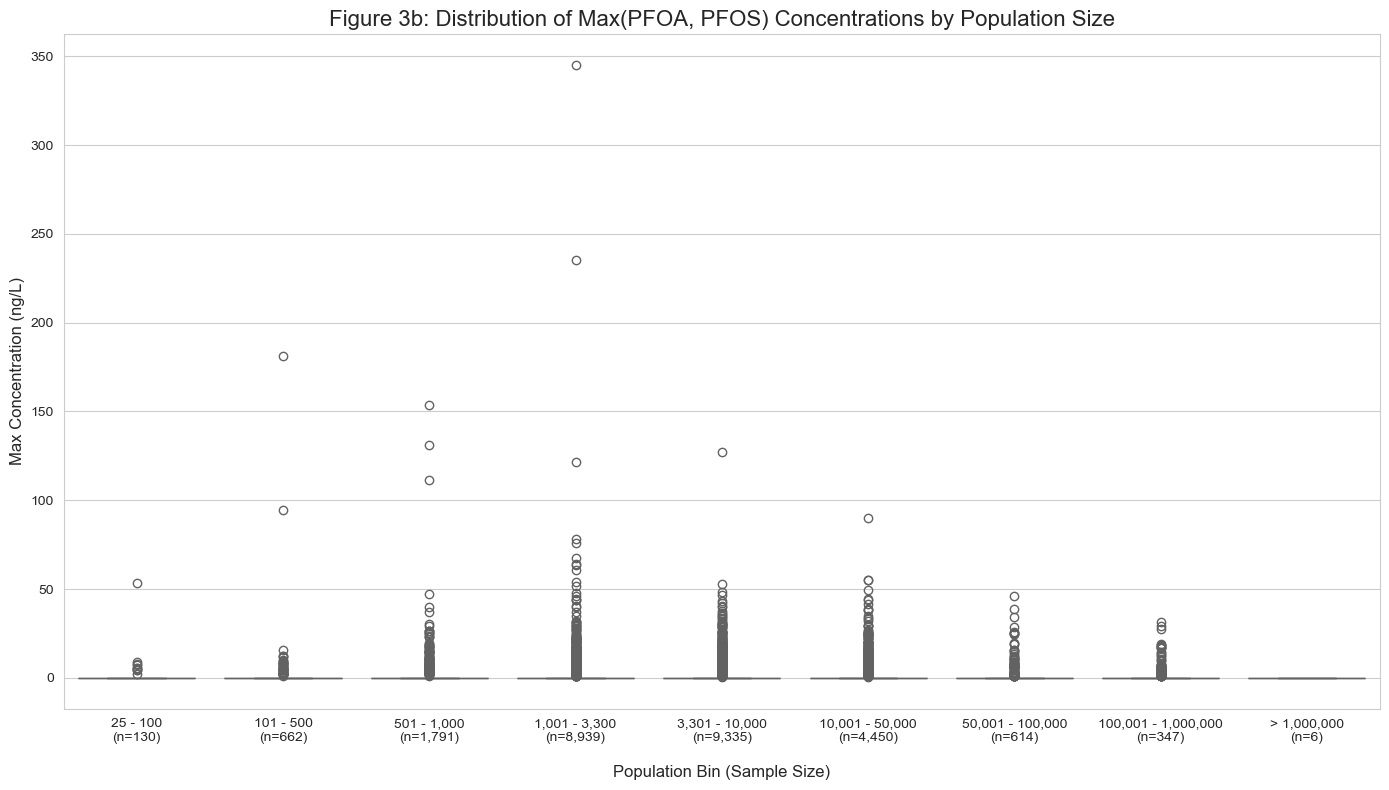

In [38]:

# Calculate counts
n_counts = df.groupby('Population_bin').size().reindex(bin_order)
new_x_labels = [f"{bin_name}\n(n={n_counts[bin_name]:,})" for bin_name in bin_order]

# Initialize Plot
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

ax = sns.boxplot(
    data=df, 
    x='Population_bin', 
    y='max_pfas_conc_ng', 
    order=bin_order,
    hue='Population_bin',
    legend=False,
    palette="Set3",
    showfliers=True
)

# Set the tick positions first, then the labels
ax.set_xticks(range(len(new_x_labels))) 
ax.set_xticklabels(new_x_labels)


plt.title("Figure 3b: Distribution of Max(PFOA, PFOS) Concentrations by Population Size", fontsize=16)
plt.xlabel("Population Bin (Sample Size)", fontsize=12, labelpad=15)
plt.ylabel("Max Concentration (ng/L)", fontsize=12)

plt.xticks(rotation=0) 


plt.tight_layout()
plt.show()

In [39]:
df

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40,exposure_per_day(ng),max_pfas_conc_ng
0,AK2110342,29349,0.0,0.0,0.0,38526.0,19263.0,"10,001 - 50,000",False,False,False,False,False,False,0.0,0.0
1,AK2110342,29360,0.0,0.0,0.0,38526.0,19263.0,"10,001 - 50,000",False,False,False,False,False,False,0.0,0.0
2,AK2110601,10001,0.0,0.0,0.0,10947.0,5474.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
3,AK2110601,10004,0.0,0.0,0.0,10947.0,5474.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
4,AK2120232,TP001,0.0,0.0,0.0,8937.0,8937.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26269,WY5601569,TP02,0.0,0.0,0.0,580.0,580.0,"501 - 1,000",False,False,False,False,False,False,0.0,0.0
26270,WY5680074,TP01,0.0,0.0,0.0,4300.0,4300.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
26271,WY5680085,TP01,0.0,0.0,0.0,7675.0,7675.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
26272,WY5680095,TP02,0.0,0.0,0.0,4514.0,4514.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
